# 01 · Data, imbalance & temporal drift setup

**Question this project answers:** *when does a neural network actually beat gradient boosting on tabular fraud data, and what breaks that advantage?*

This first notebook does three jobs:

1. **Load** the Kaggle credit-card data (or a synthetic stand-in).
2. **Expose the imbalance** — fraud is well under 1% of rows, which is why accuracy will be a useless metric later.
3. **Manufacture a controlled experiment**: we bin time into six "months" and *inject a new fraud pattern* into the last two months. Everything downstream uses this to test which models survive a shift in attacker behaviour.

> The time-binning and the injected drift are **simulations**, clearly labelled as such. The raw transactions are real (once you supply the Kaggle file); the calendar and the new attack are constructed so we can study drift in a reproducible way.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)

## Load the transactions

`load_transactions()` prefers `data/creditcard.csv`. If that file isn't there it generates a synthetic dataset with the *same schema* so the notebook still runs — the banner tells you which path was taken. Drop the real file into `data/` and re-run every notebook for real numbers.

In [2]:
df = fu.load_transactions()
print(df.shape)
df.head()

  [SYNTHETIC DATA]
  data/creditcard.csv not found - generated a stand-in so the
  pipeline runs. Drop the real file in data/ and re-run for real results.
(60200, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.6208,1.3320,-0.0748,-0.0147,-0.6127,0.9654,-0.9830,-1.5980,-0.2184,-1.7556,...,0.5937,0.5278,-0.7487,0.8489,-0.4405,1.7441,0.1864,0.0759,23.5367,0
1,0.7188,1.2145,-1.5864,-2.4253,-0.8336,-0.1448,-0.4913,-0.4932,-1.8426,0.2492,...,1.1138,0.3702,-0.0906,-1.3517,1.2006,-1.4504,-0.1539,1.0962,82.2253,0
2,1.4291,0.8590,-0.9320,0.9804,0.1563,0.0140,-0.8075,0.2232,0.8028,-0.7308,...,-0.1931,0.3213,1.0361,0.8719,-0.7069,-0.4461,-0.3542,-0.2008,236.5002,0
3,5.3931,-0.9821,-0.1884,-0.4883,-1.1697,-1.3934,0.2011,0.6286,-0.1502,-0.2028,...,-0.1554,0.3437,-2.2364,-0.7326,-0.9315,-0.7409,0.8682,0.1844,308.4785,0
4,7.3443,0.9611,-2.1100,-0.7663,-0.3997,1.7436,0.7686,-0.5572,1.3045,-0.7405,...,0.4422,-0.0609,-0.4414,0.1515,0.5503,2.0618,0.9394,0.9760,209.1286,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60200 entries, 0 to 60199
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    60200 non-null  float64
 1   V1      60200 non-null  float64
 2   V2      60200 non-null  float64
 3   V3      60200 non-null  float64
 4   V4      60200 non-null  float64
 5   V5      60200 non-null  float64
 6   V6      60200 non-null  float64
 7   V7      60200 non-null  float64
 8   V8      60200 non-null  float64
 9   V9      60200 non-null  float64
 10  V10     60200 non-null  float64
 11  V11     60200 non-null  float64
 12  V12     60200 non-null  float64
 13  V13     60200 non-null  float64
 14  V14     60200 non-null  float64
 15  V15     60200 non-null  float64
 16  V16     60200 non-null  float64
 17  V17     60200 non-null  float64
 18  V18     60200 non-null  float64
 19  V19     60200 non-null  float64
 20  V20     60200 non-null  float64
 21  V21     60200 non-null  float64
 22  V22     6

## The imbalance, stated plainly

Read the fraud rate below and remember it. A model that predicts "never fraud" for every transaction would score that same accuracy — and catch zero criminals. That is the trap notebook 04 walks into deliberately.

Class
legit    60000
fraud      200
Name: count, dtype: int64

Fraud rate: 0.3322%
A 'always legit' model would be 99.6678% accurate and catch 0 frauds.


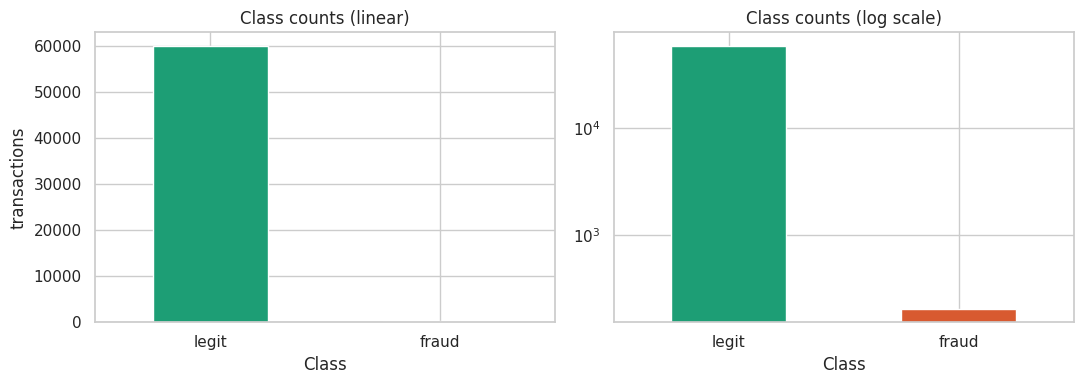

In [4]:
counts = df['Class'].value_counts().rename({0: 'legit', 1: 'fraud'})
rate = df['Class'].mean()
print(counts)
print(f"\nFraud rate: {rate:.4%}")
print(f"A 'always legit' model would be {1 - rate:.4%} accurate "
      f"and catch 0 frauds.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts.plot(kind='bar', ax=ax[0], color=['#1D9E75', '#D85A30'])
ax[0].set_title('Class counts (linear)'); ax[0].set_ylabel('transactions')
ax[0].tick_params(axis='x', rotation=0)
counts.plot(kind='bar', ax=ax[1], color=['#1D9E75', '#D85A30'], logy=True)
ax[1].set_title('Class counts (log scale)')
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## Simulate calendar time, then inject drift

The dataset spans roughly two days of `Time` (seconds). We slice that into six equal **months**, then mutate a chunk of the fraud in months 5–6 by flipping the sign of two highly-predictive PCA features (`V14`, `V4`). That mutated fraud is a signature no model trained on months 1–4 has ever seen — our stand-in for *"attackers changed tactics."*

In [5]:
df = fu.add_month_bins(df, n_months=fu.N_MONTHS)
df = fu.inject_drift(df, drift_months=fu.DRIFT_MONTHS,
                     drift_features=fu.DRIFT_FEATURES)

summary = (df.groupby('month')['Class']
             .agg(transactions='size', frauds='sum'))
summary['fraud_rate'] = summary['frauds'] / summary['transactions']
summary['drift_frauds'] = df[df['is_drift']].groupby('month').size()
summary = summary.fillna(0)
summary

,transactions,frauds,fraud_rate,drift_frauds
month,,,,
1,9989,33,0.0033,0.0000
2,10133,37,0.0037,0.0000
3,10005,27,0.0027,0.0000
4,9990,26,0.0026,0.0000
5,9982,31,0.0031,17.0000
6,10101,46,0.0046,29.0000


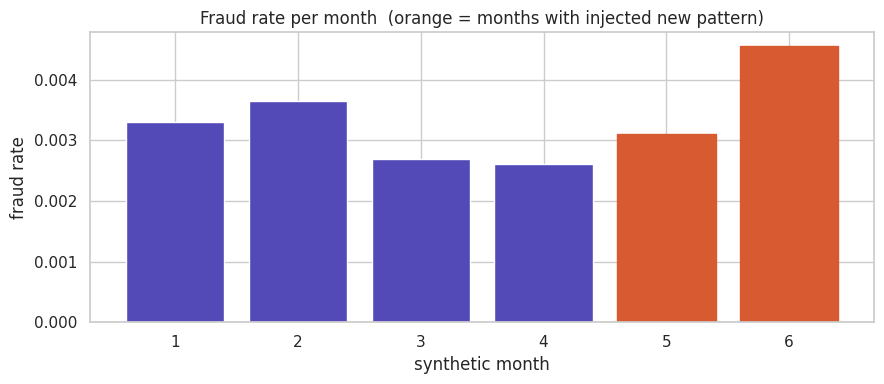

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(summary.index, summary['fraud_rate'], color='#534AB7')
for m in fu.DRIFT_MONTHS:
    ax.patches[m - 1].set_color('#D85A30')
ax.set_xlabel('synthetic month'); ax.set_ylabel('fraud rate')
ax.set_title('Fraud rate per month  (orange = months with injected new pattern)')
plt.tight_layout(); plt.show()

## Did the injection actually shift the distribution?

If drift is real, the distribution of `V14` for fraud should look different in the late months than the early ones. We overlay the two and run a Kolmogorov–Smirnov test: a small p-value means the early and late fraud distributions are *not* the same — exactly what we engineered.

KS statistic = 0.581,  p-value = 2.01e-15
Distributions differ


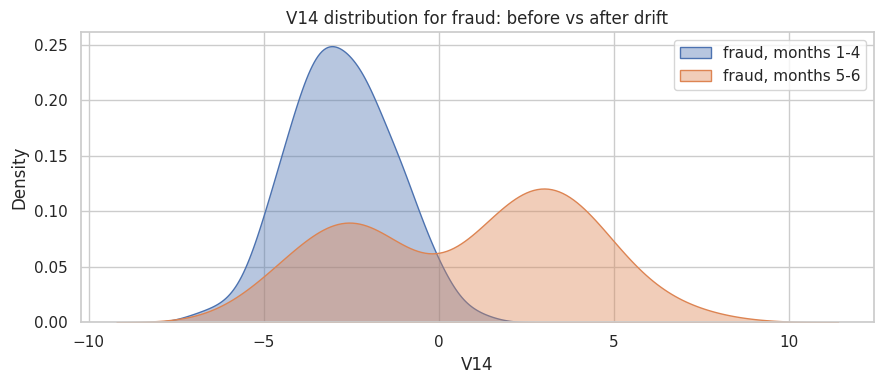

In [7]:
from scipy.stats import ks_2samp

feat = fu.DRIFT_FEATURES[0]  # 'V14'
early = df[(df['Class'] == 1) & (df['month'].isin([1, 2, 3, 4]))][feat]
late  = df[(df['Class'] == 1) & (df['month'].isin(list(fu.DRIFT_MONTHS)))][feat]

stat, p = ks_2samp(early, late)
print(f"KS statistic = {stat:.3f},  p-value = {p:.2e}")
print('Distributions differ' if p < 0.05 else 'No detectable shift')

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(early, ax=ax, label='fraud, months 1-4', fill=True, alpha=.4)
sns.kdeplot(late,  ax=ax, label='fraud, months 5-6', fill=True, alpha=.4)
ax.set_title(f'{feat} distribution for fraud: before vs after drift')
ax.legend(); plt.tight_layout(); plt.show()

## Correlation structure & amount

A quick look at how the features relate to each other and to `Class`, plus how transaction `Amount` differs between legit and fraud.

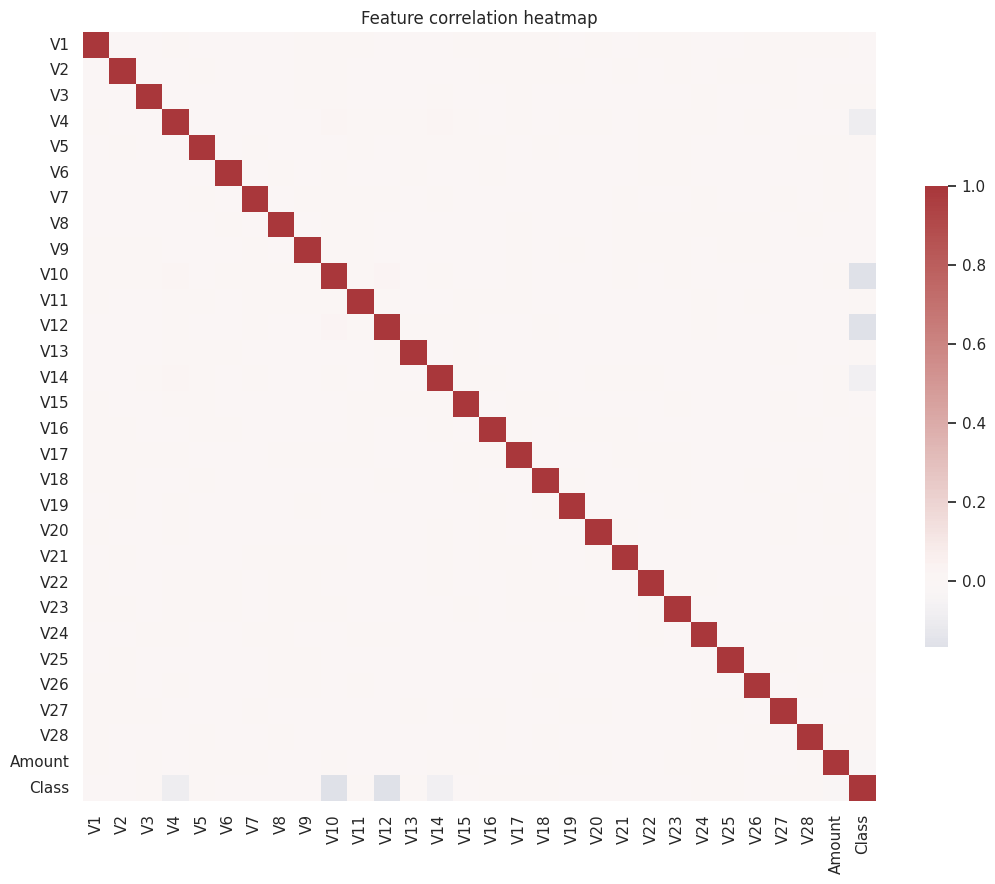

In [8]:
v_cols = [c for c in df.columns if c.startswith('V')]
corr = df[v_cols + ['Amount', 'Class']].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='vlag', center=0, ax=ax, square=False,
            cbar_kws={'shrink': .6})
ax.set_title('Feature correlation heatmap')
plt.tight_layout(); plt.show()

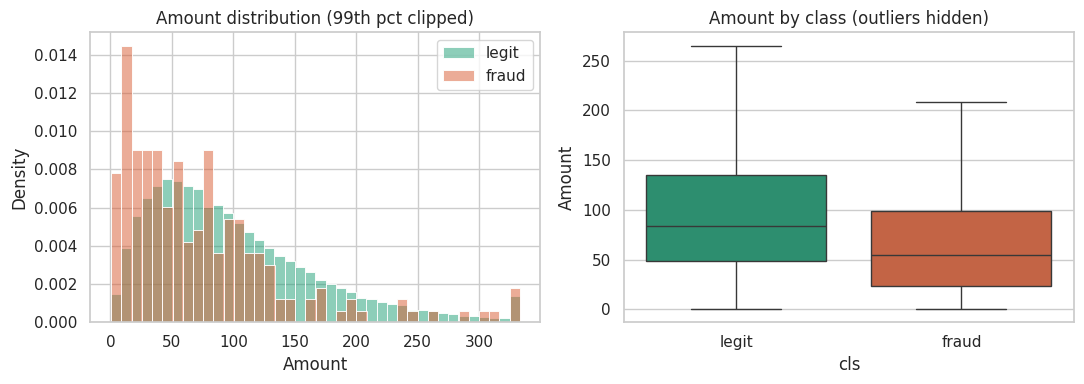

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for cls, name, color in [(0, 'legit', '#1D9E75'), (1, 'fraud', '#D85A30')]:
    sub = df[df['Class'] == cls]['Amount'].clip(upper=df['Amount'].quantile(.99))
    sns.histplot(sub, ax=ax[0], label=name, color=color, stat='density',
                 alpha=.5, bins=40)
ax[0].set_title('Amount distribution (99th pct clipped)'); ax[0].legend()
sns.boxplot(data=df.assign(cls=df['Class'].map({0: 'legit', 1: 'fraud'})),
            x='cls', y='Amount', ax=ax[1], showfliers=False,
            palette=['#1D9E75', '#D85A30'])
ax[1].set_title('Amount by class (outliers hidden)')
plt.tight_layout(); plt.show()

## Save for the next notebook

We persist the binned, drift-injected frame to `artifacts/`. Every later notebook starts by loading this, so the experiment is identical across the whole project.

In [10]:
out = os.path.join(ART, '01_data.parquet')
df.to_parquet(out, index=False)
print('saved', out, df.shape)

saved /home/claude/fraud-detection-research/artifacts/01_data.parquet (60200, 33)


### Takeaways
- Fraud is a fraction of a percent of rows — **accuracy is meaningless** here.
- We now have a reproducible **temporal axis** (6 months) and a **known, labelled drift** in months 5–6.
- The KS test confirms the late-month fraud really is a different distribution.

Next: build features that give the models a fighting chance — including ones that *don't exist* in the raw PCA columns.